<h2 style="font-family:verdana;"> <center>Assignment 3: SNS Spam Detection</center> </h2>

***
**Team Members:**
* Nhat Quang Do - 24712097 
* Minh Phuc Duong - 
* Zihao Sun -

**Date:** 29 Apr 2026 
***

### Table of Contents:
1. [<span style="font-size:18px;">Business Problem</span>](#1)

2. [<span style="font-size:18px;">Data Exploration and Preprocessing</span>](#2)

3. [<span style="font-size:18px;">Model Development</span>](#3)

4. [<span style="font-size:18px;">Model Evaluation</span>](#4)

5. [<span style="font-size:18px;">Conclusion</span>](#5)

### 1. Business Problem <a class="anchor"  id="1"></a>
---
**Problem:** 
* copy the report put it here, tell gpt to concise

**Solution**: 
* copy the report put it here, tell gpt to concise


### 2. Data Exploration and Preprocessing 
---

#### 2.1. Import Necessary Libraries
---

In [6]:
import os 
print(os.getcwd())
print(os.listdir())

/Users/boboboboghost/Desktop/NLP-Assignment3/NLP-Assignment3-SNS-SpamDetection/model
['main.ipynb', '__pycache__', 'sms_dataset', 'src']


In [8]:
# !pip install wordcloud
# Import necessary libraries
%load_ext autoreload
%autoreload 2

import os
import sys

# To store models
import joblib 

# import numpy, pandas and nltk for data manipulation and preprocessing
import pandas as pd 
import numpy as np 
import nltk

# import tensorflow for deep learning models and text preprocessing
import tensorflow as tf 
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# import necessary libraries for visualisation
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Get current directory 
current_path = os.getcwd()
sys.path.append(current_path)

# Import evaluation strategies and metrics
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score

# Import created functions and models
import src.models as models
import src.data_preprocessing as data_preprocessing


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### 2.2. Data Exploration
---

In [9]:
# Read the dataset
df_sms = data_preprocessing._read_dataset()

In [10]:
# Data Exploration
df_sms.head(5)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# Check the columns 
df_sms.columns

Index(['label', 'message'], dtype='object')

In [12]:
# Check the data information
df_sms.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [13]:
# Null values detected 
df_sms.isnull().sum()

label      0
message    0
dtype: int64

In [14]:
# Duplicated values detected
df_sms.duplicated().sum()

403

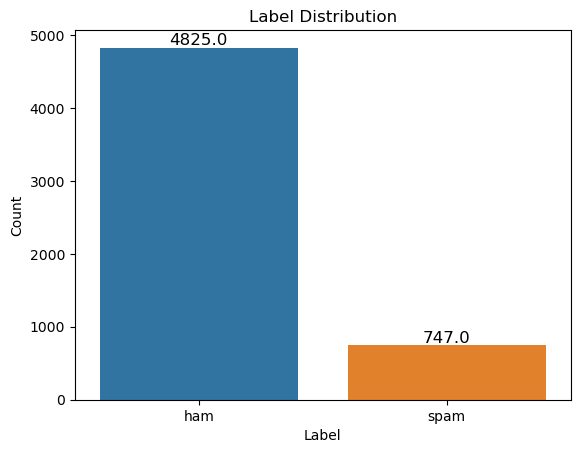

In [15]:
# Label distribution
for label in sns.countplot(x='label', data=df_sms).patches:
    count = label.get_height()
    plt.annotate(f'{count}', (label.get_x() + label.get_width() / 2, count), ha='center', va='center', fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

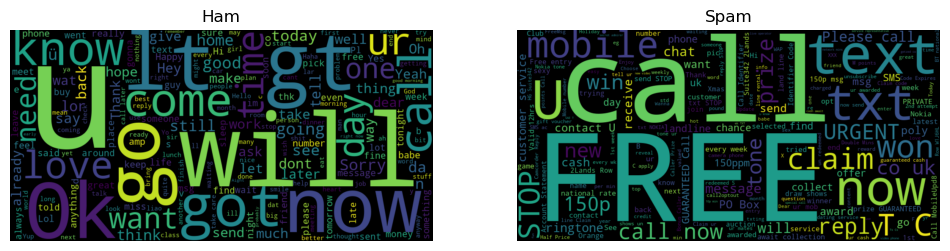

In [16]:
# Worldcloud for ham and spam messages
ham_messages = df_sms[df_sms['label'] == 'ham']['message']
spam_messages = df_sms[df_sms['label'] == 'spam']['message']
ham_wc = WordCloud(width=1000, height=500).generate(' '.join(ham_messages))
spam_wc = WordCloud(width=1000, height=500).generate(' '.join(spam_messages))
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(ham_wc, interpolation='bilinear')
plt.title('Ham')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(spam_wc, interpolation='bilinear')
plt.title('Spam')
plt.axis('off')
plt.show()

#### 2.3. Data Preprocessing
---
As previously observed in the data exploration, the dataset contains duplicates and class imbalance. In addition, during the word cloud visualisation, the most frequent words in the messages were stopwords and punctuation, which may not provide meaningful value in detecting whether a message is spam or not. The labels are also presented as text rather than numerical values, making them unsuitable for direct processing by computer algorithms. Therefore, these issues should be addressed during the data preprocessing stage, along with further preprocessing steps to transform the data into a trainable format for machine learning algorithms.

Involved steps:

1. Label Encoding: Convert labels into numerical format, where ham = 0 and spam = 1.

2. Duplicate Removal: Remove duplicated messages from the dataset.

3. Missing Value Removal: Remove rows containing missing values.

4. Train-Test Split: Split the dataset into training and testing sets, with test_size = 20%.

5. Message Preprocessing for Train/Test Sets: Apply text preprocessing separately to the training and testing sets, including tokenization, lowercasing, punctuation removal, number handling, stopword removal, and lemmatization.

Note that: 
1. Class imbalance will be handled by using appropriate evaluation metrics, such as F1-score and AUC score, to provide a more reliable assessment of model performance.

2. The preprocessed data remains in text/token format, not numerical format. Therefore, for each corresponding model, either TF-IDF or word embedding techniques will be applied later to convert the text into numerical representations.

In [17]:
X_train, X_test, y_train, y_test = data_preprocessing.data_preprocessing(df_sms)

### 3. Model Development
---

In [18]:
# Initialise the cross-validation strategy (using stratified k-fold to maintain label distribution across folds)
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=1211
)

#### 3.1. Logistic Regression ( with TD-IDF )
---

In [40]:
X_train_str = X_train.apply(lambda tokens: " ".join(tokens) for tokens in X_train)
X_test_str= X_test.apply(lambda tokens: " ".join(tokens) for tokens in X_test)

In [ ]:
# Hyperparameters for Logistic Regression
LOGISTIC_HYPERPARAMETERS = {
    'C': [0.1, 1.0, 10.0],
    'reg': ['l1', 'l2'],
    'max_iter': [50, 100]
}

In [ ]:
# Training and Hyperparameter Tuning for LR
tuner = GridSearchCV(
    estimator=models.LogisticRegression_model(),
    param_grid=LOGISTIC_HYPERPARAMETERS,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1 
)

# Train and tune
tuner.fit(X_train_str, y_train)

# Get the best model 
best_lr_model = tuner.best_estimator_
best_mean_auc = tuner.best_score_
best_std_auc = tuner.cv_results_['std_test_score'][tuner.best_index_]

print("Best LR Parameters:", tuner.best_params_)
print(f"Best LR AUC: {best_mean_auc:.4f} +- {best_std_auc:.4f}")

# Save the best model
joblib.dump(best_lr_model, "best_lr_model.pkl")

print("Done !")

#### 3.2. MultinomialNB ( with TF-IDF)
---

In [41]:
X_train_str = X_train.apply(lambda tokens: " ".join(tokens) for tokens in X_train)
X_test_str= X_test.apply(lambda tokens: " ".join(tokens) for tokens in X_test)

In [ ]:
# Hyperparameters for Multinomial Naive Bayes
NB_HYPERPARAMETERS = {
    "alpha": [0.1, 0.5, 1.0, 2.0],
    "fit_prior": [True, False],
}

In [ ]:
# Training and Hyperparameter Tuning for Multinomial Naive Bayes
tuner = GridSearchCV(
    estimator=models.MultinomialNB_model(),
    param_grid=NB_HYPERPARAMETERS,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1 
)

# Train and tune
tuner.fit(X_train_str, y_train)

# Get the best model 
best_mb_model = tuner.best_estimator_
best_mean_auc = tuner.best_score_
best_std_auc = tuner.cv_results_['std_test_score'][tuner.best_index_]

print("Best MB Parameters:", tuner.best_params_)
print(f"Best MB AUC: {best_mean_auc:.4f} +- {best_std_auc:.4f}")

# Save the best model
joblib.dump(best_mb_model, "best_mb_model.pkl")

print("Done !")

#### 3.3. LSTM ( with Word Embedding )
---

In [ ]:
# Set tokeizer
tokenizer = Tokenizer(
    num_words=5000,
    oov_token="<OOV>",
    filters=""  
)

# fit on train data only
tokenizer.fit_on_texts(X_train)

# Padding
X_train_padded = pad_sequences(
    tokenizer.texts_to_sequences(X_train),
    maxlen= 100,
    padding="post",
    truncating="post"
)

X_test_padded = pad_sequences(
    tokenizer.texts_to_sequences(X_test),
    maxlen= 100,
    padding="post",
    truncating="post"
)

# Vocab size for Embedding input_dim
vocab_size = min(5000, len(tokenizer.word_index) + 1)

In [ ]:
# Parameters for LSTM
LSTM_HYPERPARAMETERS = {
    'lstm_units': [[64, 32], [128, 64]],
    'dense_units': [[32], [64,32]],
    'dropout_rate': [0.2, 0.5],
    'lr': [0.001],
    'epochs': [50],
    'batch_size': [32]
}

In [ ]:
# Training and Hyperparameter Tuning for LSTM
tuner = GridSearchCV(
    estimator=models.LSTM_model(),
    param_grid=LSTM_HYPERPARAMETERS,
    scoring='roc_auc',
    cv=cv,
    n_jobs=1 
)

# Train and tune
tuner.fit(X_train_str, y_train)

# Get the best model 
best_lstm_model = tuner.best_estimator_
best_mean_auc = tuner.best_score_
best_std_auc = tuner.cv_results_['std_test_score'][tuner.best_index_]

print("Best LSTM Parameters:", tuner.best_params_)
print(f"Best LSTM AUC: {best_mean_auc:.4f} +- {best_std_auc:.4f}")

# Save the best model
joblib.dump(best_lstm_model, "best_lstm_model.pkl")

print("Done !")

### 4. Model Evaluation
---

In [ ]:
def evaluate(model, X_test, y_test, include_roc=True, include_cr = True, include_cm = True):
    y_pred = model.predict(X_test)
    y_pred_probs = model.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_pred_probs)
    print("AUC Score:", auc)

    # Classification Report
    if include_cr:
        print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    if include_cm:
        print("Confusion Matrix:\n")
        cfm = confusion_matrix (y_pred, y_test)
        ConfusionMatrixDisplay(confusion_matrix = cfm).plot(cmap= 'Greens')
        plt.tight_layout()
        plt.show()
    
    if include_roc:
        fpr, tpr, _ = roc_curve(y_test, y_pred_probs, pos_label=1)
        plt.plot(fpr, tpr, lw = 2, color ='red', label=f'{model.__class__.__name__} (area = {auc:.2f})' )
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') 
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('FPR')
        plt.ylabel('TPR')
        plt.title('AUC-ROC Curve Comparison')
        plt.show()



### 5. Conlcusion
---